# 02 — EDA: Descriptive → Diagnostic → Dashboard → Prescriptive

Notebook chuẩn M6a — gộp `docs/analysis/phase1_descriptive/`, `phase2_diagnostic/`,
`phase3_dashboard/`, `phase4_prescriptive/` (script `.py` gốc, đã QC ở `phase0_qc_report.md`)
thành 1 notebook, port lại đúng công thức/kết luận — KHÔNG tính lại từ đầu theo cách khác.

**Nguồn dữ liệu**: đọc qua `datathon.config` / `datathon.ingestion.load_raw()` (KHÔNG hardcode
path CSV). **TODO (chưa làm được)**: M3a/M3b (dbt staging + marts) CHƯA xong tại thời điểm viết
notebook này (`PROCESS.md` M3a = ⬜ pending) → đọc thẳng 14 bảng **raw CSV**, tự join/tính lại
trong notebook (giống các script gốc). Khi M3b xong, thay các cell load ở mục 0 bằng
`SELECT * FROM iceberg.marts.*` qua Trino, phần logic phân tích phía dưới giữ nguyên.

**Business fact quan trọng** (từ `data/README.md`, M7): `sales.csv` = GROSS revenue (đối chiếu
Phần B forecast); `net_revenue` (Gross - discount - refund) chỉ dùng Phần A; `payments.payment_value`
= Monetary trong RFM.

Cấu trúc 4 phần theo `RESTRUCTURE_AGENTS.md` mục M6:
1. **Descriptive** — trend/mùa vụ/Tết (⇐ `phase1_descriptive/eda_training_charts.py`,
   `tet_effect.py`).
2. **Diagnostic** — vì sao (⇐ `phase2_diagnostic/revenue_diagnostic.py`).
3. **Dashboard** — demographics + RFM + cohort (⇐ `phase3_dashboard/customer_demographics.py`).
4. **Prescriptive** — 3 đề xuất định lượng (⇐ `phase4_prescriptive/prescriptive_analysis.py`).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # notebook vẫn hiện inline qua %matplotlib inline bên dưới
import matplotlib.pyplot as plt
from lunardate import LunarDate

from datathon import config
from datathon.ingestion import load_raw

%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
AGE_ORDER = ["18-24", "25-34", "35-44", "45-54", "55+"]

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

print("DATA_RAW:", config.DATA_RAW)


DATA_RAW: /Users/lhoanghai_/Documents/Study/Dự án datathon2026/data/raw


## 0. Load dữ liệu — qua `datathon.config` / `load_raw()` (raw CSV, chưa có mart dbt)

In [2]:
sales = load_raw("sales")
orders = load_raw("orders")
items = load_raw("order_items")
products = load_raw("products")
customers = load_raw("customers")
geography = load_raw("geography")
promotions = load_raw("promotions")
returns = load_raw("returns")
payments = load_raw("payments")

for name, df in [("sales", sales), ("orders", orders), ("order_items", items),
                  ("products", products), ("customers", customers),
                  ("geography", geography), ("promotions", promotions),
                  ("returns", returns), ("payments", payments)]:
    print(f"{name:14s} {df.shape}")


sales          (3833, 3)
orders         (646945, 8)
order_items    (714669, 7)
products       (2412, 8)
customers      (121930, 7)
geography      (39948, 4)
promotions     (50, 10)
returns        (39939, 7)
payments       (646945, 4)


## Phần 1 — Descriptive (⇐ `phase1_descriptive/`)

Nguồn duy nhất: `sales.csv` (GROSS revenue theo ngày). 6 chart quan sát + hiệu ứng Tết —
port nguyên công thức từ `eda_training_charts.py` / `tet_effect.py`.


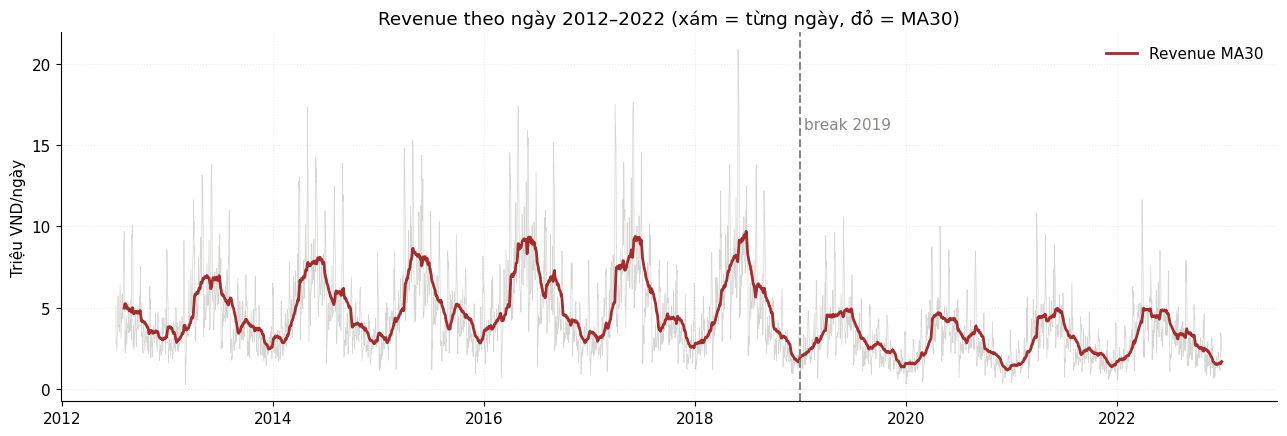

In [3]:
sales = sales.rename(columns={"Date": "Date"}).sort_values("Date").reset_index(drop=True)
sales["margin_pct"] = (sales["Revenue"] - sales["COGS"]) / sales["Revenue"] * 100
sales["MA30"] = sales["Revenue"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sales["Date"], sales["Revenue"] / 1e6, color=C_GRAY, alpha=0.35, lw=0.5)
ax.plot(sales["Date"], sales["MA30"] / 1e6, color=C_REV, lw=2, label="Revenue MA30")
ax.axvline(pd.Timestamp("2019-01-01"), color=C_GRAY, ls="--", lw=1.5)
ax.annotate("break 2019", xy=(pd.Timestamp("2019-01-15"), 16), color=C_GRAY)
ax.set_ylabel("Triệu VND/ngày")
ax.set_title("Revenue theo ngày 2012–2022 (xám = từng ngày, đỏ = MA30)")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


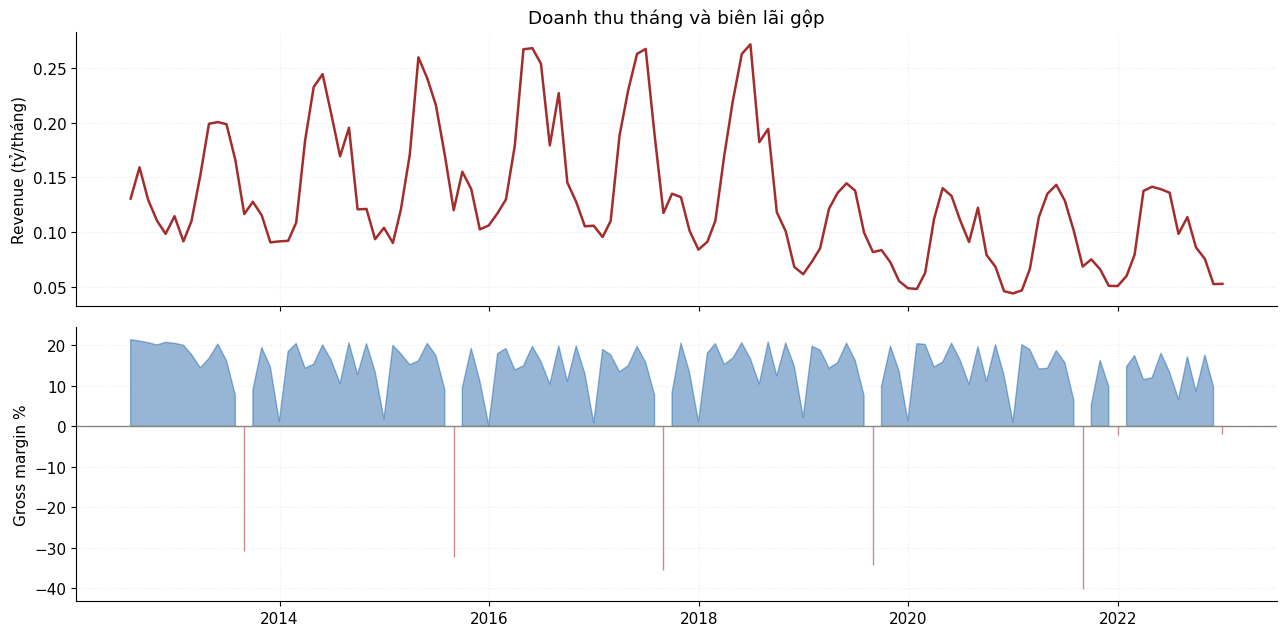

In [4]:
monthly = sales.set_index("Date").resample("ME")[["Revenue", "COGS"]].sum()
monthly["margin_pct"] = (monthly["Revenue"] - monthly["COGS"]) / monthly["Revenue"] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax1.plot(monthly.index, monthly["Revenue"] / 1e9, color=C_REV, lw=1.8)
ax1.set_ylabel("Revenue (tỷ/tháng)")
ax1.set_title("Doanh thu tháng và biên lãi gộp")
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] >= 0, color=C_COGS, alpha=0.45)
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] < 0, color=C_REV, alpha=0.55)
ax2.axhline(0, color=C_GRAY, lw=1)
ax2.set_ylabel("Gross margin %")
fig.tight_layout(); plt.show()


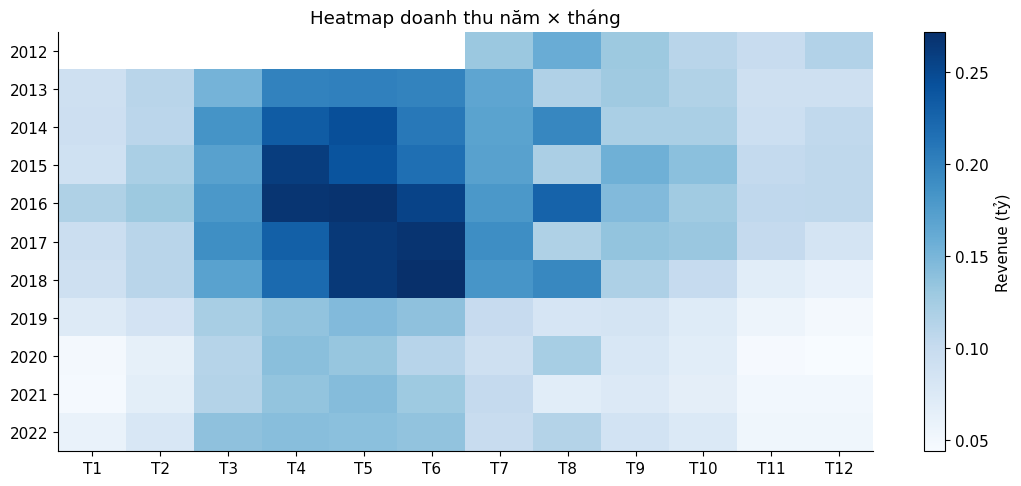

In [5]:
hm = sales.pivot_table(index=sales["Date"].dt.year, columns=sales["Date"].dt.month,
                       values="Revenue", aggfunc="sum") / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(hm.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(12), [f"T{m}" for m in range(1, 13)])
ax.set_yticks(range(len(hm.index)), hm.index)
ax.grid(False)
fig.colorbar(im, label="Revenue (tỷ)")
ax.set_title("Heatmap doanh thu năm × tháng")
fig.tight_layout(); plt.show()


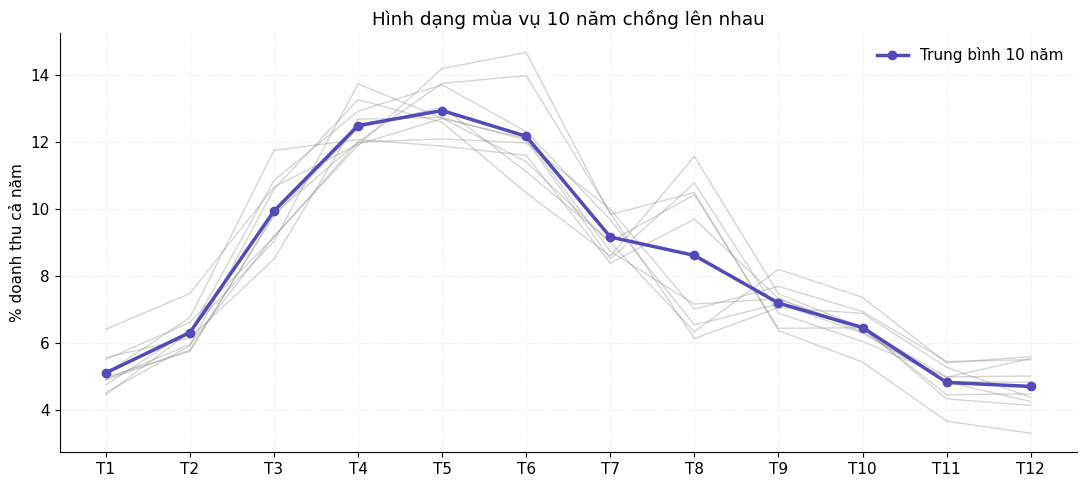

Tỷ trọng tháng (TB % ± std qua 10 năm):
  T1 :  5.11% +/- 0.58
  T2 :  6.32% +/- 0.53
  T3 :  9.95% +/- 1.01
  T4 : 12.50% +/- 0.64
  T5 : 12.95% +/- 0.74
  T6 : 12.18% +/- 1.27
  T7 :  9.17% +/- 0.62
  T8 :  8.62% +/- 2.15
  T9 :  7.20% +/- 0.55
  T10:  6.47% +/- 0.53
  T11:  4.83% +/- 0.55
  T12:  4.71% +/- 0.74


In [6]:
yr = sales[sales["Date"].dt.year.between(2013, 2022)].copy()
yr["year"], yr["month"] = yr["Date"].dt.year, yr["Date"].dt.month
share = (yr.groupby(["year", "month"])["Revenue"].sum()
         / yr.groupby("year")["Revenue"].sum()).unstack() * 100

fig, ax = plt.subplots(figsize=(11, 5))
for y in share.index:
    ax.plot(share.columns, share.loc[y], color=C_GRAY, alpha=0.35, lw=1)
ax.plot(share.columns, share.mean(), color=C_ACCENT, lw=2.5, marker="o", label="Trung bình 10 năm")
ax.set_xticks(range(1, 13), [f"T{m}" for m in range(1, 13)])
ax.set_ylabel("% doanh thu cả năm")
ax.set_title("Hình dạng mùa vụ 10 năm chồng lên nhau")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

print("Tỷ trọng tháng (TB % ± std qua 10 năm):")
for m in range(1, 13):
    print(f"  T{m:<2}: {share[m].mean():5.2f}% +/- {share[m].std():.2f}")


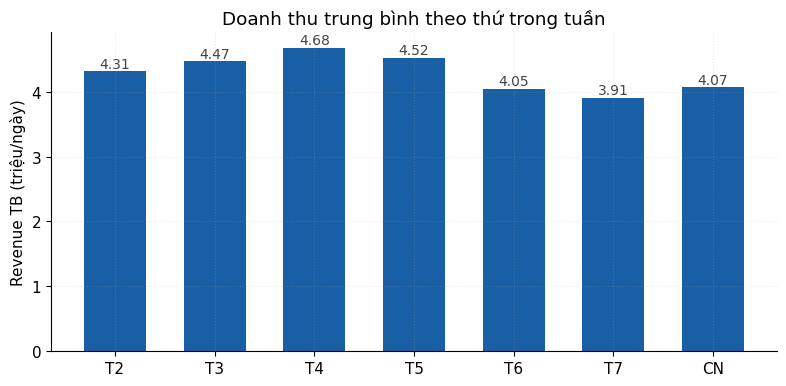

Chênh cao nhất vs thấp nhất trong tuần: 19.8%


In [7]:
dow = sales.groupby(sales["Date"].dt.dayofweek)["Revenue"].mean() / 1e6
labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, dow.values, color=C_COGS, width=0.62)
for i, v in enumerate(dow.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10, color="#444441")
ax.set_ylabel("Revenue TB (triệu/ngày)")
ax.set_title("Doanh thu trung bình theo thứ trong tuần")
fig.tight_layout(); plt.show()

print(f"Chênh cao nhất vs thấp nhất trong tuần: {(dow.max()/dow.min()-1)*100:.1f}%")


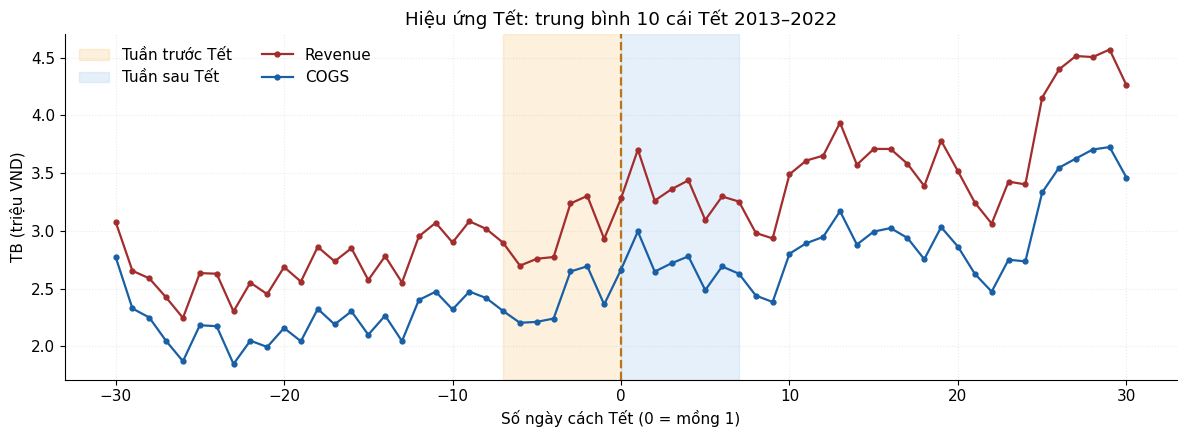

Corr(Revenue, COGS) theo ngày: 0.9760
Tỷ lệ COGS/Revenue: TB 0.875, std 0.127
Top 5 ngày doanh thu cao nhất:
  2018-05-30    20.9 triệu
  2018-05-31    19.3 triệu
  2018-06-01    19.2 triệu
  2017-06-01    17.6 triệu
  2018-06-02    17.5 triệu


In [8]:
tet_dates = [pd.Timestamp(LunarDate(y, 1, 1).to_solar_date()) for y in range(2013, 2023)]
frames = []
for t in tet_dates:
    w = sales[(sales["Date"] >= t - pd.Timedelta(days=30)) &
              (sales["Date"] <= t + pd.Timedelta(days=30))].copy()
    w["offset"] = (w["Date"] - t).dt.days
    frames.append(w)
avg = pd.concat(frames).groupby("offset")[["Revenue", "COGS"]].mean() / 1e6

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axvspan(-7, 0, color="#FAC775", alpha=0.25, label="Tuần trước Tết")
ax.axvspan(0, 7, color="#B5D4F4", alpha=0.35, label="Tuần sau Tết")
ax.axvline(0, color="#BA7517", ls="--", lw=1.6)
ax.plot(avg.index, avg["Revenue"], "o-", color=C_REV, ms=3.5, lw=1.6, label="Revenue")
ax.plot(avg.index, avg["COGS"], "o-", color=C_COGS, ms=3.5, lw=1.6, label="COGS")
ax.set_xlabel("Số ngày cách Tết (0 = mồng 1)")
ax.set_ylabel("TB (triệu VND)")
ax.set_title("Hiệu ứng Tết: trung bình 10 cái Tết 2013–2022")
ax.legend(frameon=False, ncol=2)
fig.tight_layout(); plt.show()

print(f"Corr(Revenue, COGS) theo ngày: {sales['Revenue'].corr(sales['COGS']):.4f}")
print(f"Tỷ lệ COGS/Revenue: TB {(sales['COGS']/sales['Revenue']).mean():.3f}, "
      f"std {(sales['COGS']/sales['Revenue']).std():.3f}")
top5 = sales.nlargest(5, "Revenue")[["Date", "Revenue"]]
print("Top 5 ngày doanh thu cao nhất:")
for _, r in top5.iterrows():
    print(f"  {r['Date'].date()}  {r['Revenue']/1e6:6.1f} triệu")


**Diễn giải (mô tả)**: doanh thu có xu hướng tăng 2013-2018 rồi gãy mạnh từ 2019 (xem MA30 +
heatmap); mùa vụ lặp lại khá ổn định qua 10 năm (đường trung bình mượt, các năm bám sát nhau);
Tết tạo 1 đỉnh ngắn quanh mồng 1 rồi dip nhẹ sau đó. Phần Diagnostic bên dưới trả lời **vì sao**
có break 2019.


## Phần 2 — Diagnostic (⇐ `phase2_diagnostic/revenue_diagnostic.py`)

Join `order_items` (grain = 1 dòng/sản phẩm/đơn) với `orders/products/customers/geography/promotions`
để trả lời "vì sao" đằng sau các chart Descriptive. `line_revenue = quantity * unit_price` (GROSS,
khớp `sales.csv` — sanity check bên dưới).


In [9]:
# customers đã có sẵn cột 'zip' (khác bản gốc chỉ usecols acquisition_channel/signup_date) ->
# drop trước khi merge để tránh đụng 'zip' đã có từ orders (tránh bị pandas tự suffix zip_x/zip_y).
customers_nozip = customers.drop(columns=["zip"])

li = (items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(customers_nozip, on="customer_id", how="left")
      .merge(geography, on="zip", how="left")
      .merge(promotions, on="promo_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
li["year"] = li["order_date"].dt.year
li["month"] = li["order_date"].dt.month
li = li[li["year"].between(2013, 2022)].copy()

chk = li.groupby(li["order_date"])["line_revenue"].sum()
sales_idx = sales.set_index("Date")["Revenue"]
diff = ((chk.reindex(sales_idx.index) - sales_idx).abs() / sales_idx).mean() * 100
print(f"Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: {diff:.3f}% (kỳ vọng ~0%)")
print(f"{len(li):,} dòng sau join, {li['customer_id'].nunique():,} khách")


Sanity check — sai lệch rebuilt (line_revenue) vs sales.csv: 0.000% (kỳ vọng ~0%)
677,662 dòng sau join, 89,063 khách


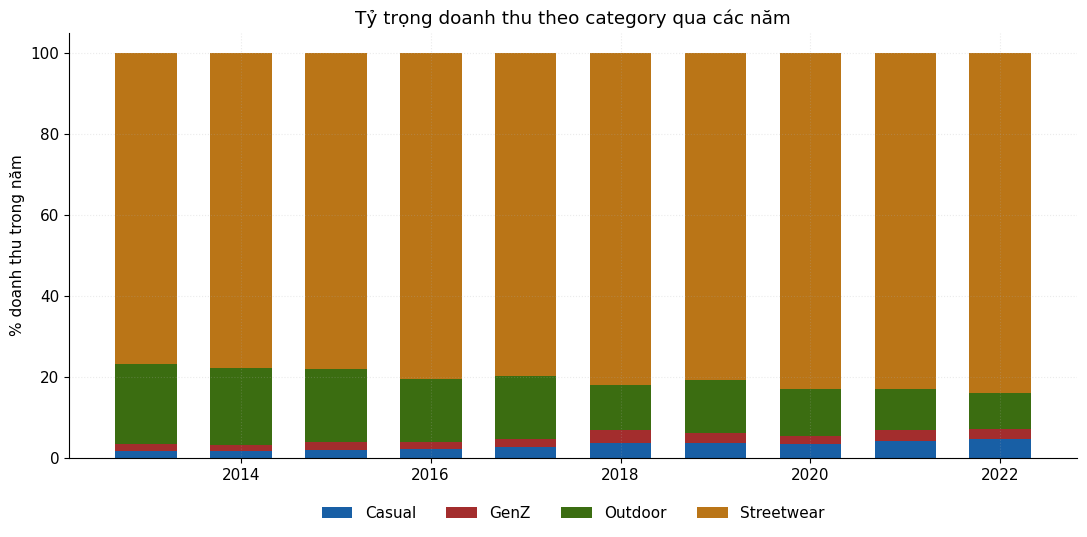

2013: {'Casual': 1.8, 'GenZ': 1.6, 'Outdoor': 19.8, 'Streetwear': 76.8}
2022: {'Casual': 4.6, 'GenZ': 2.5, 'Outdoor': 9.0, 'Streetwear': 83.8}


In [10]:
cat_yr = li.groupby(["year", "category"])["line_revenue"].sum().unstack()
cat_share = cat_yr.div(cat_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(cat_share))
for i, cat in enumerate(cat_share.columns):
    ax.bar(cat_share.index, cat_share[cat], bottom=bottom, label=cat,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += cat_share[cat].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo category qua các năm")
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); plt.show()

print(f"2013: {cat_share.loc[2013].round(1).to_dict()}")
print(f"2022: {cat_share.loc[2022].round(1).to_dict()}")


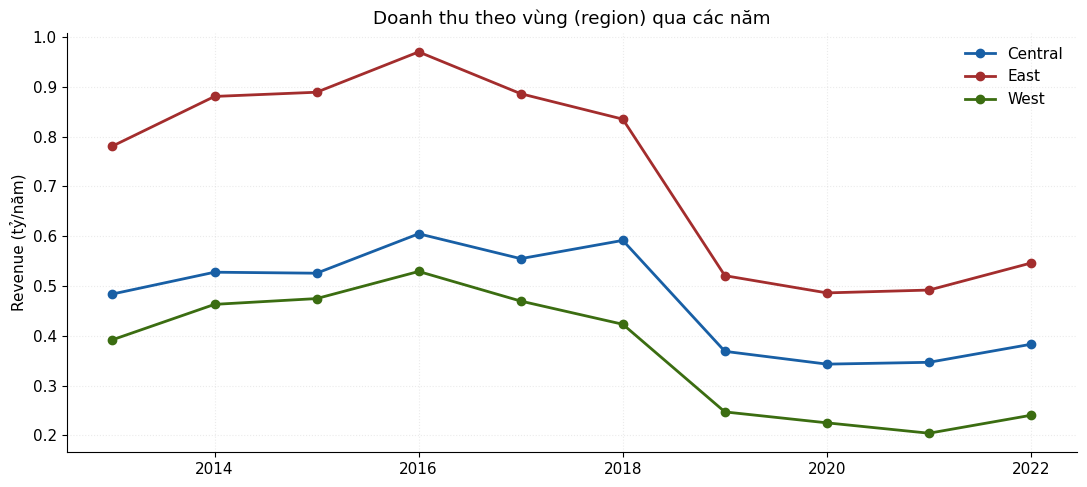

2022 (tỷ VND): {'Central': 0.4, 'East': 0.5, 'West': 0.2}


In [11]:
reg_yr = li.groupby(["year", "region"])["line_revenue"].sum().unstack() / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
for i, reg in enumerate(reg_yr.columns):
    ax.plot(reg_yr.index, reg_yr[reg], "o-", color=PALETTE[i % len(PALETTE)], lw=2, label=reg)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo vùng (region) qua các năm")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()
print(f"2022 (tỷ VND): {reg_yr.loc[2022].round(1).to_dict()}")


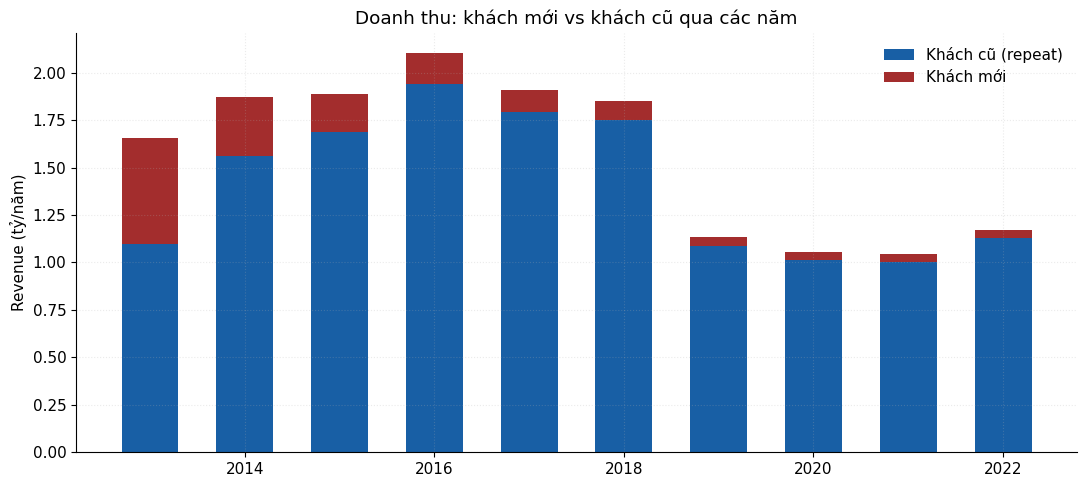

Tỷ trọng revenue từ khách cũ (repeat): {2013: np.float64(66.1), 2018: np.float64(94.7), 2019: np.float64(95.6), 2022: np.float64(96.4)}


In [12]:
first_order = orders.groupby("customer_id")["order_date"].min().rename("first_order_date")
li2 = li.merge(first_order, on="customer_id", how="left")
li2["cust_type"] = np.where(li2["order_date"] == li2["first_order_date"], "Khách mới", "Khách cũ (repeat)")
nr_yr = li2.groupby(["year", "cust_type"])["line_revenue"].sum().unstack() / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(nr_yr.index, nr_yr["Khách cũ (repeat)"], color=C_COGS, label="Khách cũ (repeat)", width=0.6)
ax.bar(nr_yr.index, nr_yr["Khách mới"], bottom=nr_yr["Khách cũ (repeat)"], color=C_REV, label="Khách mới", width=0.6)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu: khách mới vs khách cũ qua các năm")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

repeat_share = (nr_yr["Khách cũ (repeat)"] / nr_yr.sum(axis=1) * 100)
print("Tỷ trọng revenue từ khách cũ (repeat):",
      {y: round(repeat_share.loc[y], 1) for y in [2013, 2018, 2019, 2022]})


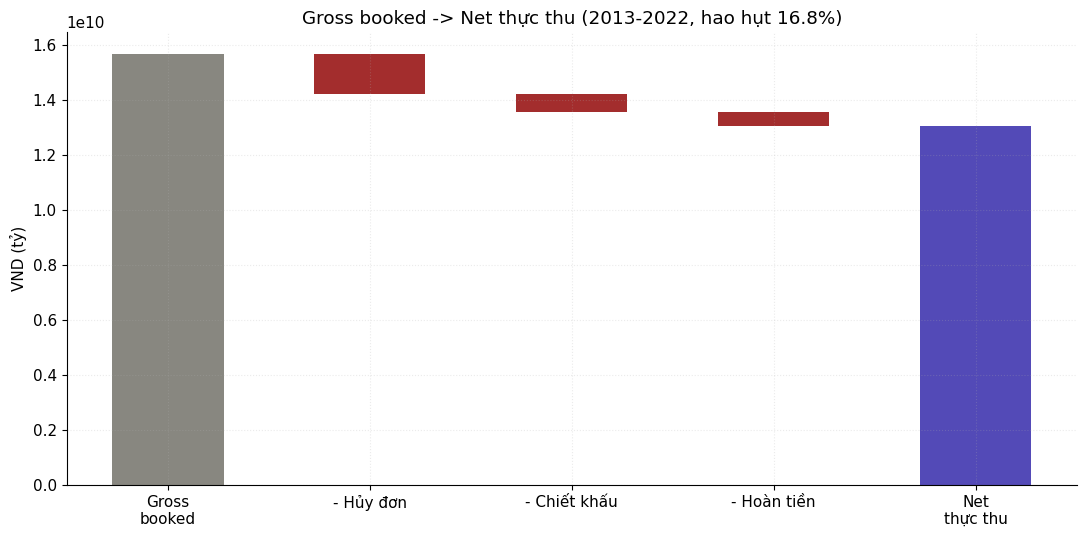

Gross booked   :    15.69 tỷ
- Hủy đơn      :    -1.45 tỷ (9.2%)
- Chiết khấu   :    -0.68 tỷ (4.3%)
- Hoàn tiền    :    -0.51 tỷ (3.3%)
= Net thực thu :    13.05 tỷ (83.2% của gross)


In [13]:
gross = li["line_revenue"].sum()
cancelled_loss = li.loc[li["order_status"] == "cancelled", "line_revenue"].sum()
after_cancel = gross - cancelled_loss
discount_loss = li.loc[li["order_status"] != "cancelled", "discount_amount"].sum()
after_discount = after_cancel - discount_loss
refund_loss = returns["refund_amount"].sum()
net_final = after_discount - refund_loss

stages = ["Gross\nbooked", "- Hủy đơn", "- Chiết khấu", "- Hoàn tiền", "Net\nthực thu"]
bar_bottoms = [0, after_cancel, after_discount, net_final, 0]
bar_heights = [gross, cancelled_loss, discount_loss, refund_loss, net_final]
colors = [C_GRAY, C_REV, C_REV, C_REV, C_ACCENT]

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, (s, h, c) in enumerate(zip(bar_bottoms, bar_heights, colors)):
    ax.bar(i, h, bottom=s, color=c, width=0.55)
ax.set_xticks(range(5), stages)
ax.set_ylabel("VND (tỷ)")
ax.set_title(f"Gross booked -> Net thực thu (2013-2022, hao hụt {(1-net_final/gross)*100:.1f}%)")
fig.tight_layout(); plt.show()

print(f"Gross booked   : {gross/1e9:8.2f} tỷ")
print(f"- Hủy đơn      : {-cancelled_loss/1e9:8.2f} tỷ ({cancelled_loss/gross*100:.1f}%)")
print(f"- Chiết khấu   : {-discount_loss/1e9:8.2f} tỷ ({discount_loss/gross*100:.1f}%)")
print(f"- Hoàn tiền    : {-refund_loss/1e9:8.2f} tỷ ({refund_loss/gross*100:.1f}%)")
print(f"= Net thực thu : {net_final/1e9:8.2f} tỷ ({net_final/gross*100:.1f}% của gross)")


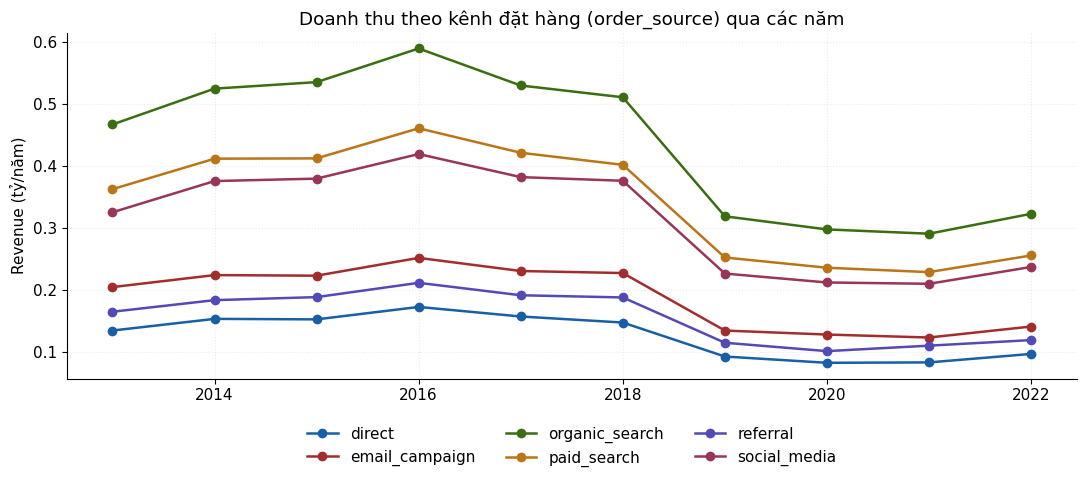

Sụt giảm revenue 2018->2019 theo kênh (%): {'direct': -37.4, 'email_campaign': -41.0, 'organic_search': -37.7, 'paid_search': -37.3, 'referral': -39.1, 'social_media': -39.9}


In [14]:
src_yr = li.groupby(["year", "order_source"])["line_revenue"].sum().unstack() / 1e9
fig, ax = plt.subplots(figsize=(11, 5))
for i, src in enumerate(src_yr.columns):
    ax.plot(src_yr.index, src_yr[src], "o-", color=PALETTE[i % len(PALETTE)], lw=1.8, label=src)
ax.set_ylabel("Revenue (tỷ/năm)")
ax.set_title("Doanh thu theo kênh đặt hàng (order_source) qua các năm")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout(); plt.show()

drop_by_channel = (src_yr.loc[2019] / src_yr.loc[2018] - 1) * 100
print("Sụt giảm revenue 2018->2019 theo kênh (%):", drop_by_channel.round(1).to_dict())


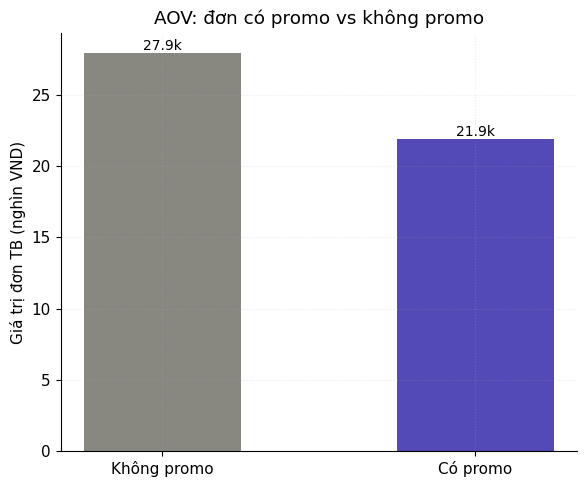

AOV không promo: 27,945 VND | AOV có promo: 21,896 VND (chênh -21.6%)


In [15]:
li["has_promo"] = li["promo_id"].notna()
order_val = li.groupby(["order_id", "has_promo"])["line_revenue"].sum().reset_index()
aov = order_val.groupby("has_promo")["line_revenue"].mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Không promo", "Có promo"], aov.values / 1e3, color=[C_GRAY, C_ACCENT], width=0.5)
for i, v in enumerate(aov.values / 1e3):
    ax.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax.set_title("AOV: đơn có promo vs không promo")
fig.tight_layout(); plt.show()

print(f"AOV không promo: {aov[False]:,.0f} VND | AOV có promo: {aov[True]:,.0f} VND "
      f"(chênh {(aov[True]/aov[False]-1)*100:+.1f}%)")


### Q1 — Vì sao 2019-2021 sụt mạnh? Tách ASP (giá) vs khối lượng


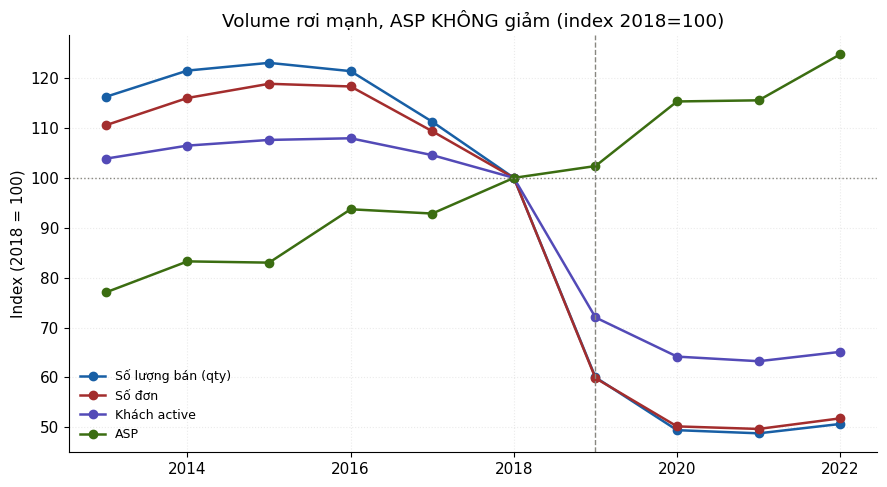

2018->2019: Revenue -38.6% | ASP +2.4% | Qty -40.0% | Số đơn -40.2% | Khách active -28.0%
-> ASP KHÔNG giảm; sụt giảm gần như toàn bộ đến từ khối lượng (qty/số đơn) + khách active rơi.


In [16]:
yr_kpi = li.groupby("year").agg(revenue=("line_revenue", "sum"), qty=("quantity", "sum")).reset_index()
yr_kpi["ASP"] = yr_kpi["revenue"] / yr_kpi["qty"]

ord_all = orders.assign(year=orders["order_date"].dt.year)
ord_all = ord_all[ord_all["year"].between(2013, 2022)]
n_orders = ord_all.groupby("year")["order_id"].nunique().rename("n_orders")
n_active_cust = ord_all.groupby("year")["customer_id"].nunique().rename("n_active_cust")
yr_kpi = yr_kpi.merge(n_orders, on="year").merge(n_active_cust, on="year")
yr_kpi["AOV"] = yr_kpi["revenue"] / yr_kpi["n_orders"]
base = yr_kpi.set_index("year")

idx100 = base / base.loc[2018] * 100
fig, ax = plt.subplots(figsize=(9, 5))
for col, c, lbl in [("qty", C_COGS, "Số lượng bán (qty)"), ("n_orders", C_REV, "Số đơn"),
                     ("n_active_cust", C_ACCENT, "Khách active"), ("ASP", "#3B6D11", "ASP")]:
    ax.plot(base.index, idx100[col], "o-", color=c, lw=1.8, label=lbl)
ax.axhline(100, color=C_GRAY, ls=":", lw=1)
ax.axvline(2019, color=C_GRAY, ls="--", lw=1)
ax.set_ylabel("Index (2018 = 100)")
ax.set_title("Volume rơi mạnh, ASP KHÔNG giảm (index 2018=100)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

r18, r19 = base.loc[2018], base.loc[2019]
print(f"2018->2019: Revenue {(r19['revenue']/r18['revenue']-1)*100:+.1f}% | "
      f"ASP {(r19['ASP']/r18['ASP']-1)*100:+.1f}% | Qty {(r19['qty']/r18['qty']-1)*100:+.1f}% | "
      f"Số đơn {(r19['n_orders']/r18['n_orders']-1)*100:+.1f}% | "
      f"Khách active {(r19['n_active_cust']/r18['n_active_cust']-1)*100:+.1f}%")
print("-> ASP KHÔNG giảm; sụt giảm gần như toàn bộ đến từ khối lượng (qty/số đơn) + khách active rơi.")


### Q2 — Cơ chế lỗ gộp: tỷ lệ bán dưới giá vốn, có promo vs không promo


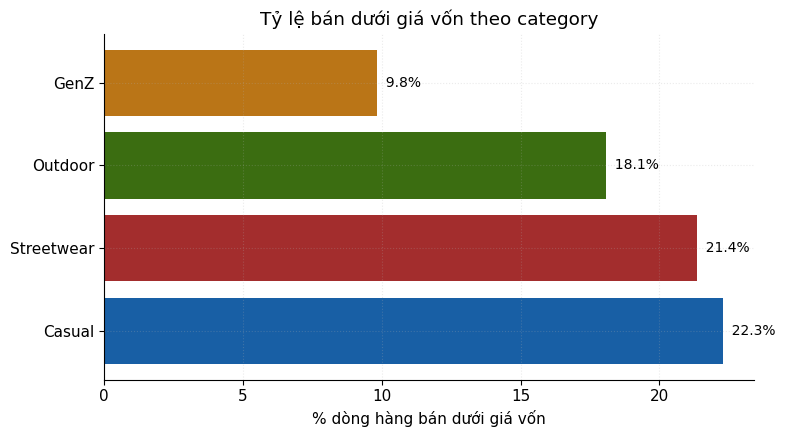

% dòng bán dưới giá vốn KHI có promo    : 47.86%
% dòng bán dưới giá vốn KHI KHÔNG có promo: 0.18%
-> promotion là nguyên nhân trực tiếp cơ chế lỗ gộp (bán dưới giá vốn tập trung ở dòng có promo).


In [17]:
li["below_cost"] = li["unit_price"] < li["cogs"]
overall_bc_promo = li.loc[li["has_promo"], "below_cost"].mean() * 100
overall_bc_nopromo = li.loc[~li["has_promo"], "below_cost"].mean() * 100

bc_cat = li.groupby("category").agg(
    n_lines=("below_cost", "size"),
    pct_lineitems_below_cost=("below_cost", "mean"),
).reset_index()
bc_cat["pct_lineitems_below_cost"] *= 100
bc_cat = bc_cat.sort_values("pct_lineitems_below_cost", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(bc_cat["category"], bc_cat["pct_lineitems_below_cost"], color=PALETTE[:len(bc_cat)])
for i, v in enumerate(bc_cat["pct_lineitems_below_cost"]):
    ax.text(v, i, f"  {v:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% dòng hàng bán dưới giá vốn")
ax.set_title("Tỷ lệ bán dưới giá vốn theo category")
fig.tight_layout(); plt.show()

print(f"% dòng bán dưới giá vốn KHI có promo    : {overall_bc_promo:.2f}%")
print(f"% dòng bán dưới giá vốn KHI KHÔNG có promo: {overall_bc_nopromo:.2f}%")
print("-> promotion là nguyên nhân trực tiếp cơ chế lỗ gộp (bán dưới giá vốn tập trung ở dòng có promo).")


**Diễn giải (chẩn đoán)**: break doanh thu 2019 đến từ **khối lượng** (qty/số đơn/khách active
rơi ~30-40%), KHÔNG phải giá bán (ASP ổn định/tăng nhẹ) — loại trừ giả thuyết "giảm giá gây sụt
doanh thu". Sụt giảm xảy ra **đồng loạt ở mọi kênh order_source** cùng lúc (mục kênh ở trên) →
đây là vấn đề hệ thống (nguồn cung/thị trường/khách rời bỏ), không phải 1 kênh marketing yếu đi.
Margin âm (bán dưới giá vốn) gắn chặt với dòng CÓ promo — cơ chế lỗ gộp chủ yếu do khuyến mãi định
giá dưới cost, không phải do chi phí COGS tăng. **Lưu ý**: đây là quan sát mô tả trên dữ liệu mô
phỏng — KHÔNG suy diễn nhân quả tuyệt đối nếu không có thêm biến ngoại sinh (vd cạnh tranh thị
trường, thay đổi chính sách) mà bộ dữ liệu không có.


## Phần 3 — Dashboard: Demographics + RFM + Cohort (⇐ `phase3_dashboard/customer_demographics.py`)


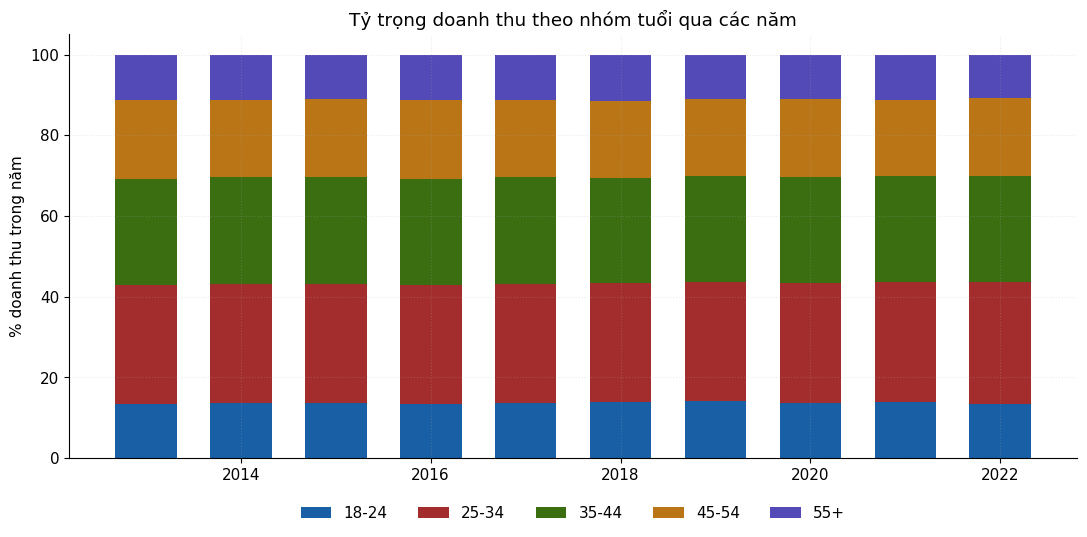

In [18]:
li["age_group"] = pd.Categorical(li["age_group"], categories=AGE_ORDER, ordered=True)
age_yr = li.groupby(["year", "age_group"], observed=True)["line_revenue"].sum().unstack()
age_share = age_yr.div(age_yr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(age_share))
for i, ag in enumerate(AGE_ORDER):
    ax.bar(age_share.index, age_share[ag], bottom=bottom, label=ag,
           color=PALETTE[i % len(PALETTE)], width=0.65)
    bottom += age_share[ag].values
ax.set_ylabel("% doanh thu trong năm")
ax.set_title("Tỷ trọng doanh thu theo nhóm tuổi qua các năm")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); plt.show()


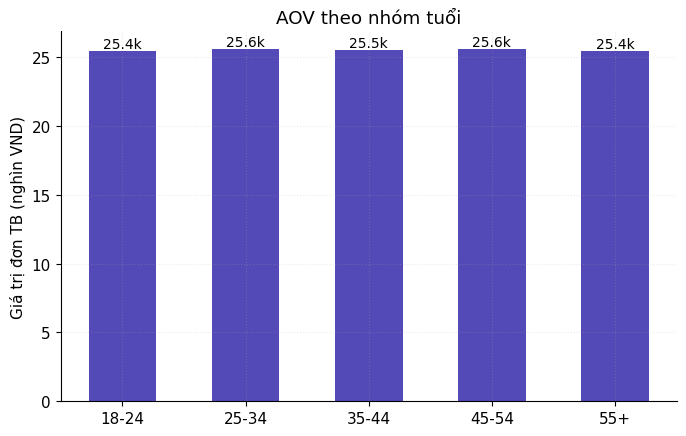

AOV theo tuổi (nghìn VND): {'18-24': 25.42, '25-34': 25.56, '35-44': 25.5, '45-54': 25.59, '55+': 25.42}


In [19]:
order_val_age = li.groupby(["order_id", "age_group"], observed=True)["line_revenue"].sum().reset_index()
aov_age = order_val_age.groupby("age_group", observed=True)["line_revenue"].mean().reindex(AGE_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(aov_age.index, aov_age.values / 1e3, color=C_ACCENT, width=0.55)
for i, v in enumerate(aov_age.values / 1e3):
    ax.text(i, v, f"{v:.1f}k", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Giá trị đơn TB (nghìn VND)")
ax.set_title("AOV theo nhóm tuổi")
fig.tight_layout(); plt.show()
print("AOV theo tuổi (nghìn VND):", (aov_age / 1e3).round(2).to_dict())


### RFM Segmentation

Recency = số ngày từ đơn KHÔNG-cancelled gần nhất tới ngày cuối dữ liệu.
Frequency = số đơn không-cancelled. Monetary = tổng `payments.payment_value` (net thực thu).


In [20]:
SNAPSHOT_DATE = orders["order_date"].max()
non_cancel = orders[orders["order_status"] != "cancelled"].merge(
    payments[["order_id", "payment_value"]], on="order_id", how="left")

rfm = non_cancel.groupby("customer_id").agg(
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
).reset_index()
rfm["recency_days"] = (SNAPSHOT_DATE - rfm["last_order"]).dt.days

def qscore(s, labels):
    ranks = s.rank(method="first")
    return pd.qcut(ranks, 5, labels=labels).astype(int)

rfm["R_score"] = qscore(rfm["recency_days"], [5, 4, 3, 2, 1])
rfm["F_score"] = qscore(rfm["frequency"], [1, 2, 3, 4, 5])
rfm["M_score"] = qscore(rfm["monetary"], [1, 2, 3, 4, 5])

def rfm_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3 and m >= 3: return "Loyal Customers"
    if r >= 4 and f <= 2: return "New Customers"
    if r == 3 and f <= 2: return "Promising"
    if r <= 2 and f >= 4 and m >= 4: return "Can't Lose Them"
    if r <= 2 and f >= 3: return "At Risk"
    if r <= 2 and f <= 2 and m >= 3: return "Hibernating"
    if r <= 2 and f <= 2: return "Lost"
    return "Need Attention"

rfm["segment"] = rfm.apply(rfm_segment, axis=1)
seg_summary = (rfm.groupby("segment")
               .agg(n_customers=("customer_id", "count"),
                    total_monetary=("monetary", "sum"),
                    avg_recency=("recency_days", "mean"),
                    avg_frequency=("frequency", "mean"))
               .sort_values("total_monetary", ascending=False))
seg_summary["pct_customers"] = seg_summary["n_customers"] / seg_summary["n_customers"].sum() * 100
seg_summary["pct_monetary"] = seg_summary["total_monetary"] / seg_summary["total_monetary"].sum() * 100
seg_summary.round(2)


,n_customers,total_monetary,avg_recency,avg_frequency,pct_customers,pct_monetary
segment,,,,,,
Champions,22575,8.949596e+09,274.23,15.88,25.62,62.88
Loyal Customers,16974,2.884125e+09,787.01,7.02,19.26,20.26
At Risk,7989,6.461639e+08,2009.51,3.90,9.07,4.54
Can't Lose Them,2251,4.920698e+08,1782.76,8.61,2.55,3.46
Lost,21682,4.587557e+08,2562.65,1.26,24.60,3.22
Hibernating,3327,2.696038e+08,2398.74,1.60,3.78,1.89
Promising,5375,2.054179e+08,1105.38,1.48,6.10,1.44
New Customers,4865,2.033228e+08,359.00,1.51,5.52,1.43
Need Attention,3085,1.248016e+08,688.95,3.65,3.50,0.88


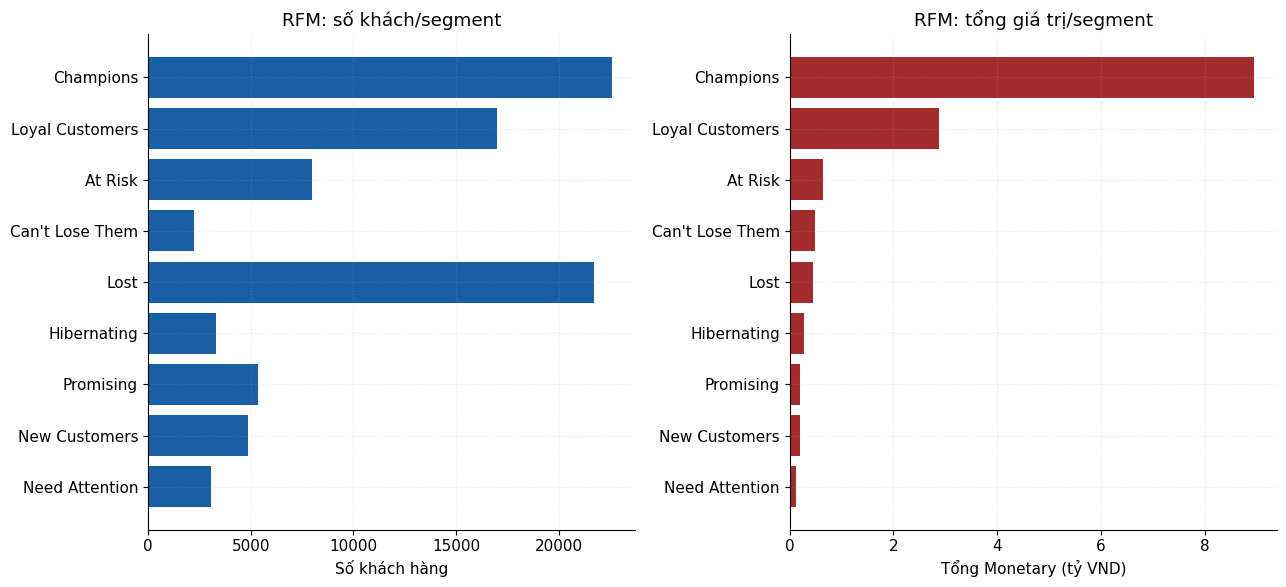

In [21]:
order_idx = seg_summary.index
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(order_idx, seg_summary["n_customers"], color=PALETTE[0])
axes[0].invert_yaxis(); axes[0].set_xlabel("Số khách hàng"); axes[0].set_title("RFM: số khách/segment")
axes[1].barh(order_idx, seg_summary["total_monetary"] / 1e9, color=PALETTE[1])
axes[1].invert_yaxis(); axes[1].set_xlabel("Tổng Monetary (tỷ VND)"); axes[1].set_title("RFM: tổng giá trị/segment")
fig.tight_layout(); plt.show()


### Cohort Retention (theo tháng signup)

Khách signup trước ngày mở bán (`2012-07-04`) tách riêng, không tính vào cohort chính.


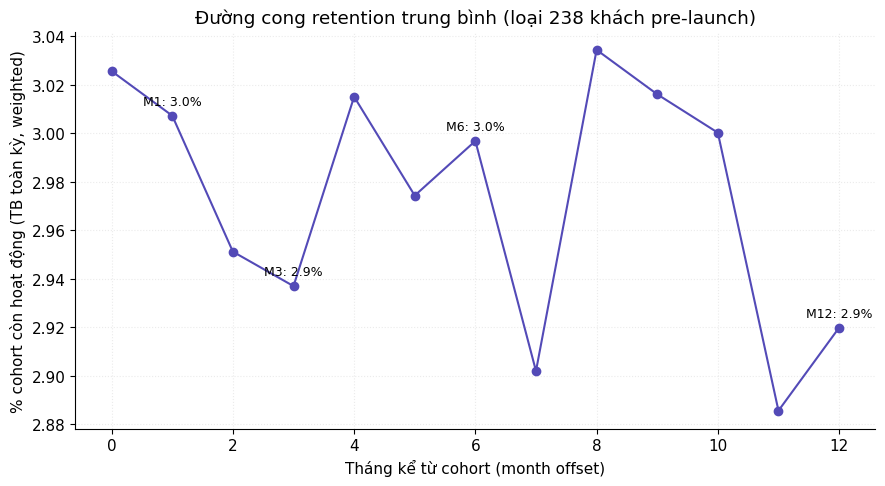

Retention mốc: {'M1': 3.0, 'M3': 2.9, 'M6': 3.0, 'M12': 2.9}
Cohort chính: 121,692 khách, 126 cohort tháng


In [22]:
SHOP_OPEN = pd.Timestamp("2012-07-04")
customers_full = customers.copy()
customers_full["signup_date"] = pd.to_datetime(customers_full["signup_date"])
is_pre_launch = customers_full["signup_date"] < SHOP_OPEN
pre_launch = customers_full[is_pre_launch].copy()
cohort_customers = customers_full[~is_pre_launch].copy()
cohort_customers["cohort_month"] = cohort_customers["signup_date"].dt.to_period("M")

orders_nc = non_cancel[["customer_id", "order_date"]].copy()
orders_nc["order_month"] = orders_nc["order_date"].dt.to_period("M")

merged = orders_nc.merge(cohort_customers[["customer_id", "cohort_month"]], on="customer_id", how="inner")
merged["month_offset"] = ((merged["order_month"].dt.year - merged["cohort_month"].dt.year) * 12
                           + (merged["order_month"].dt.month - merged["cohort_month"].dt.month))
merged = merged[merged["month_offset"] >= 0]

cohort_sizes = cohort_customers.groupby("cohort_month")["customer_id"].nunique()
active = merged.groupby(["cohort_month", "month_offset"])["customer_id"].nunique().unstack()

max_month = orders_nc["order_month"].max()
avg_retention = {}
for off in range(0, 13):
    eligible = cohort_sizes.index[cohort_sizes.index + off <= max_month]
    denom = cohort_sizes.loc[eligible].sum()
    numer = active.reindex(index=eligible, columns=[off]).fillna(0).sum().iloc[0] if off in active.columns else 0
    avg_retention[off] = numer / denom * 100 if denom > 0 else np.nan
avg_retention = pd.Series(avg_retention)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(avg_retention.index, avg_retention.values, marker="o", color=C_ACCENT)
for m in [1, 3, 6, 12]:
    if m in avg_retention.index:
        ax.annotate(f"M{m}: {avg_retention[m]:.1f}%", (m, avg_retention[m]),
                    textcoords="offset points", xytext=(0, 8), fontsize=9, ha="center")
ax.set_xlabel("Tháng kể từ cohort (month offset)")
ax.set_ylabel("% cohort còn hoạt động (TB toàn kỳ, weighted)")
ax.set_title(f"Đường cong retention trung bình (loại {len(pre_launch)} khách pre-launch)")
fig.tight_layout(); plt.show()

print("Retention mốc:", {f"M{k}": round(v, 1) for k, v in avg_retention.items() if k in [1, 3, 6, 12]})
print(f"Cohort chính: {len(cohort_customers):,} khách, {cohort_sizes.shape[0]} cohort tháng")


**Diễn giải (dashboard)**: doanh thu tập trung nhóm tuổi 25-44 và khá ổn định qua năm (không có
dịch chuyển nhân khẩu học lớn giải thích break 2019). RFM cho thấy phân bố giá trị khách hàng
lệch — vài segment nhỏ (`Champions`/`Loyal`) đóng góp tỷ trọng Monetary lớn hơn tỷ trọng số khách
(xem `pct_customers` vs `pct_monetary`). Retention rơi mạnh nhất ở tháng đầu (M1) rồi giảm dần —
điển hình theo cơ chế "first purchase drop-off" của e-commerce.


## Phần 4 — Prescriptive (⇐ `phase4_prescriptive/prescriptive_analysis.py`)

3 đề xuất định lượng — đều là **kịch bản mô phỏng trên dữ liệu lịch sử** (what-if), KHÔNG phải dự
báo. Dùng lại đúng dataframe đã tính ở Phần 2/3 trong cùng notebook (không phụ thuộc CSV trung
gian cũ).

### Đề xuất 1 — Floor price cho promotion (không bán dưới giá vốn)


Tổng dòng order_items (toàn bộ lịch sử): 714,669 | dưới giá vốn: 133,052 (18.62%)
Margin thực tế: 13.80% (2.267 tỷ VND)
Margin nếu áp floor price = cogs: 16.15% (2.729 tỷ VND)
=> Margin tăng thêm: +2.36 điểm % , +0.462 tỷ VND


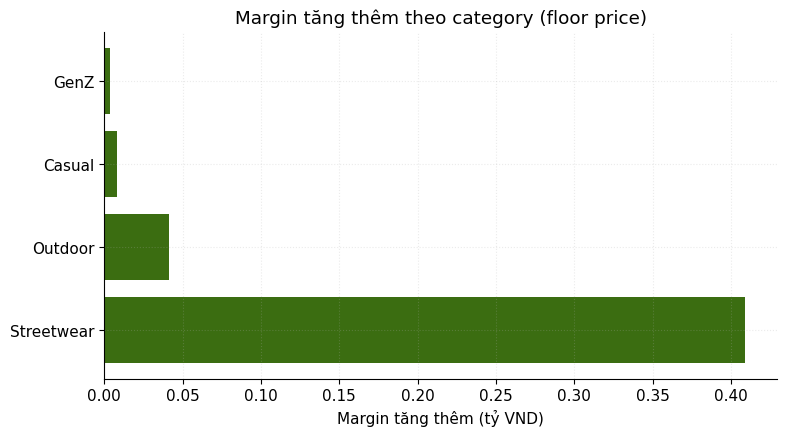

In [23]:
li_full = items.merge(products[["product_id", "category", "cogs", "price"]], on="product_id", how="left")
li_full["line_revenue"] = li_full["quantity"] * li_full["unit_price"]
li_full["line_cogs"] = li_full["quantity"] * li_full["cogs"]
li_full["unit_price_floor"] = np.maximum(li_full["unit_price"], li_full["cogs"])
li_full["line_revenue_floor"] = li_full["quantity"] * li_full["unit_price_floor"]

n_total = len(li_full)
n_below = (li_full["unit_price"] < li_full["cogs"]).sum()

rev_actual = li_full["line_revenue"].sum()
cogs_actual = li_full["line_cogs"].sum()
margin_actual_pct = (1 - cogs_actual / rev_actual) * 100
margin_actual_vnd = rev_actual - cogs_actual

rev_floor = li_full["line_revenue_floor"].sum()
margin_floor_pct = (1 - cogs_actual / rev_floor) * 100
margin_floor_vnd = rev_floor - cogs_actual
margin_gain_vnd = margin_floor_vnd - margin_actual_vnd
margin_gain_pp = margin_floor_pct - margin_actual_pct

print(f"Tổng dòng order_items (toàn bộ lịch sử): {n_total:,} | dưới giá vốn: {n_below:,} "
      f"({n_below/n_total*100:.2f}%)")
print(f"Margin thực tế: {margin_actual_pct:.2f}% ({margin_actual_vnd/1e9:.3f} tỷ VND)")
print(f"Margin nếu áp floor price = cogs: {margin_floor_pct:.2f}% ({margin_floor_vnd/1e9:.3f} tỷ VND)")
print(f"=> Margin tăng thêm: +{margin_gain_pp:.2f} điểm % , +{margin_gain_vnd/1e9:.3f} tỷ VND")

cat_g = li_full.groupby("category").agg(
    revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum"),
    revenue_floor=("line_revenue_floor", "sum")).reset_index()
cat_g["margin_gain_vnd"] = ((cat_g["revenue_floor"] - cat_g["cogs"]) - (cat_g["revenue"] - cat_g["cogs"]))
cat_g = cat_g.sort_values("margin_gain_vnd", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(cat_g["category"], cat_g["margin_gain_vnd"] / 1e9, color=PALETTE[2])
ax.set_xlabel("Margin tăng thêm (tỷ VND)")
ax.set_title("Margin tăng thêm theo category (floor price)")
fig.tight_layout(); plt.show()


### Đề xuất 2 — Win-back theo RFM segment (`Can't Lose Them`, `At Risk`)

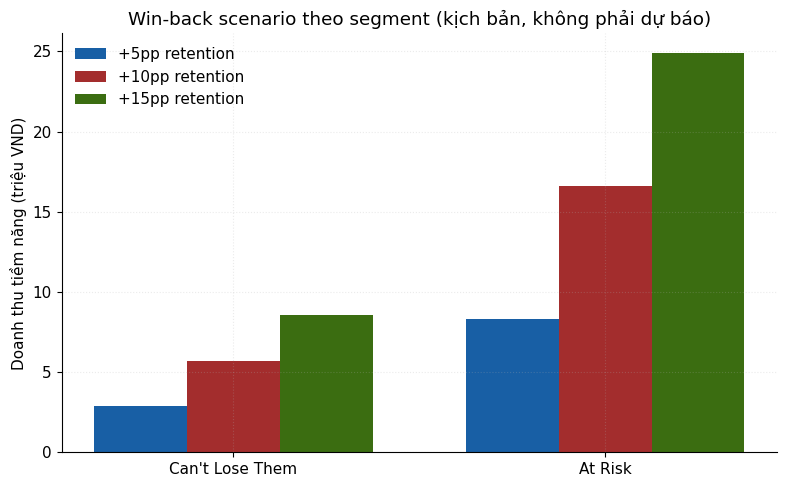

,segment,n_customers,avg_order_value_vnd,uplift_scenario_pct,n_customers_retained_est,revenue_potential_vnd
0,Can't Lose Them,2251,25393.2,5.0,112.6,2858006.9
1,Can't Lose Them,2251,25393.2,10.0,225.1,5716013.8
2,Can't Lose Them,2251,25393.2,15.0,337.6,8574020.7
3,At Risk,7989,20756.3,5.0,399.5,8291098.0
4,At Risk,7989,20756.3,10.0,798.9,16582196.1
5,At Risk,7989,20756.3,15.0,1198.4,24873294.1


In [24]:
target_segments = ["Can't Lose Them", "At Risk"]
uplift_scenarios = [0.05, 0.10, 0.15]  # kịch bản +X điểm % retention, KHÔNG phải dự báo

rows = []
for seg in target_segments:
    sub = rfm[rfm["segment"] == seg]
    n_cust = len(sub)
    total_monetary = sub["monetary"].sum()
    total_frequency = sub["frequency"].sum()
    aov = total_monetary / total_frequency if total_frequency else np.nan
    for x in uplift_scenarios:
        n_retained = n_cust * x
        revenue_potential = n_retained * aov
        rows.append({"segment": seg, "n_customers": n_cust, "avg_order_value_vnd": aov,
                     "uplift_scenario_pct": x * 100, "n_customers_retained_est": n_retained,
                     "revenue_potential_vnd": revenue_potential})
winback = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.25
x_pos = np.arange(len(target_segments))
for i, x in enumerate(uplift_scenarios):
    vals = [winback[(winback.segment == s) & (winback.uplift_scenario_pct == x*100)]["revenue_potential_vnd"].values[0] / 1e6
            for s in target_segments]
    ax.bar(x_pos + i*width, vals, width=width, label=f"+{x*100:.0f}pp retention", color=PALETTE[i])
ax.set_xticks(x_pos + width); ax.set_xticklabels(target_segments)
ax.set_ylabel("Doanh thu tiềm năng (triệu VND)")
ax.set_title("Win-back scenario theo segment (kịch bản, không phải dự báo)")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()
winback.round(1)


### Đề xuất 3 — Nhân rộng pricing practice của vùng margin tốt nhất

Margin toàn phần theo region: {'West': 14.2, 'East': 13.31, 'Central': 13.15}
Vùng margin tốt nhất: West

Giả định: các vùng còn lại đạt 60% khoảng cách margin so với 'West' trong cùng category
Margin toàn shop hiện tại: 13.47%
=> Tổng margin tăng thêm: +0.038 tỷ VND
=> Margin toàn shop mới: 13.71% (+0.24 điểm %)


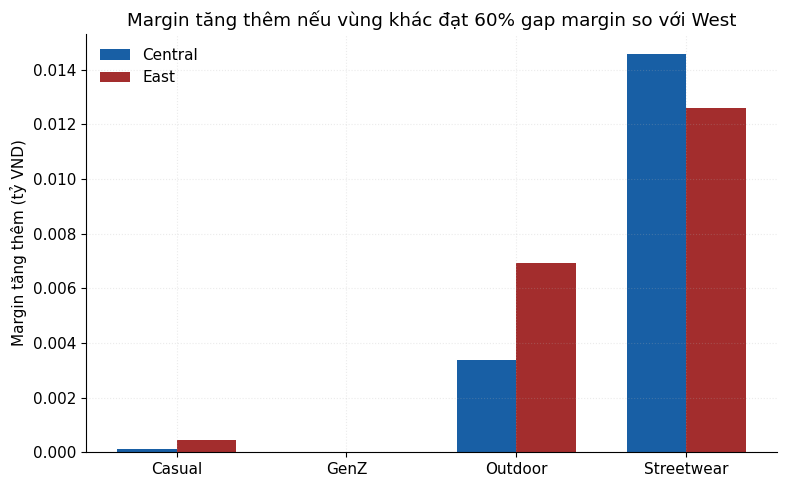

In [25]:
rc = li.groupby(["region", "category"]).agg(revenue=("line_revenue", "sum"), cogs=("line_cogs", "sum")).reset_index()
rc["margin_pct"] = (rc["revenue"] - rc["cogs"]) / rc["revenue"] * 100
region_margin_overall = li.groupby("region").apply(
    lambda g: (g["line_revenue"].sum() - g["line_cogs"].sum()) / g["line_revenue"].sum() * 100,
    include_groups=False).sort_values(ascending=False)
BEST_REGION = region_margin_overall.index[0]
print("Margin toàn phần theo region:", region_margin_overall.round(2).to_dict())
print(f"Vùng margin tốt nhất: {BEST_REGION}")

PRICE_EFFECT_SHARE = 0.60  # giả định ~60% chênh lệch margin do giá thật tốt hơn (Phase 2 Q3)
best = rc[rc.region == BEST_REGION].set_index("category")["margin_pct"]

rows3 = []
for reg in [r for r in rc["region"].unique() if r != BEST_REGION]:
    sub = rc[rc.region == reg].copy()
    sub["best_region_margin_pct"] = sub["category"].map(best)
    sub["gap_pp"] = sub["best_region_margin_pct"] - sub["margin_pct"]
    sub["gap_pp_positive"] = sub["gap_pp"].clip(lower=0)
    sub["target_margin_pct"] = sub["margin_pct"] + PRICE_EFFECT_SHARE * sub["gap_pp_positive"]
    sub["cogs_new"] = sub["revenue"] * (1 - sub["target_margin_pct"] / 100)
    sub["margin_gain_vnd"] = sub["cogs"] - sub["cogs_new"]
    rows3.append(sub)
repl = pd.concat(rows3, ignore_index=True)

total_gain = repl["margin_gain_vnd"].sum()
total_revenue_all = rc["revenue"].sum()
total_cogs_all = rc["cogs"].sum()
margin_pct_before = (1 - total_cogs_all / total_revenue_all) * 100
margin_pct_after = (1 - (total_cogs_all - total_gain) / total_revenue_all) * 100

print(f"\nGiả định: các vùng còn lại đạt {PRICE_EFFECT_SHARE*100:.0f}% khoảng cách margin so với "
      f"'{BEST_REGION}' trong cùng category")
print(f"Margin toàn shop hiện tại: {margin_pct_before:.2f}%")
print(f"=> Tổng margin tăng thêm: +{total_gain/1e9:.3f} tỷ VND")
print(f"=> Margin toàn shop mới: {margin_pct_after:.2f}% (+{margin_pct_after-margin_pct_before:.2f} điểm %)")

fig, ax = plt.subplots(figsize=(8, 5))
cats = repl["category"].unique()
x_pos = np.arange(len(cats))
regions_other = repl["region"].unique()
width = 0.35
for i, reg in enumerate(regions_other):
    vals = [repl[(repl.category == c) & (repl.region == reg)]["margin_gain_vnd"].values[0] / 1e9
            for c in cats]
    ax.bar(x_pos + i*width, vals, width=width, label=reg, color=PALETTE[i])
ax.set_xticks(x_pos + width/2); ax.set_xticklabels(cats)
ax.set_ylabel("Margin tăng thêm (tỷ VND)")
ax.set_title(f"Margin tăng thêm nếu vùng khác đạt {PRICE_EFFECT_SHARE*100:.0f}% gap margin so với {BEST_REGION}")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


## Hạn chế của phân tích (toàn notebook)

- Dữ liệu là **e-commerce mô phỏng** (không phải giao dịch thật) — số tuyệt đối không đại diện
  thị trường thật, chỉ dùng để luyện kỹ năng phân tích/pipeline.
- Đọc trực tiếp **raw CSV** qua `datathon.config` (M3a/M3b dbt marts CHƯA xong tại thời điểm viết
  — xem `PROCESS.md`). Khi mart xong, cần re-run và đối chiếu số liệu không đổi (regression).
- Phần Diagnostic dùng **quan sát tương quan** (vd promo vs below-cost, promo vs Tết dip) — KHÔNG
  chứng minh nhân quả; mẫu Tết chỉ 10 năm, corr chỉ mang tính gợi ý.
- Phần Prescriptive là **kịch bản what-if tĩnh** trên dữ liệu lịch sử (elasticity giá/nhu cầu
  không được model — floor price giả định khách vẫn mua đúng volume cũ dù giá tăng; win-back giả
  định tỷ lệ quay lại; nhân rộng pricing giả định margin gap không có nguyên nhân cấu trúc khác
  ngoài giá) — cần thử nghiệm A/B thật trước khi triển khai diện rộng.
- Bỏ qua phần logistic-regression churn model (dashboard gốc `customer_demographics.py` mục 28) —
  ngoài phạm vi "descriptive/diagnostic/dashboard/prescriptive" của M6a; vẫn còn nguyên trong
  `docs/analysis/phase3_dashboard/` nếu cần tham khảo.

## Đề xuất tiếp theo

1. Khi M3b xong: chuyển mục 0 sang đọc `iceberg.marts.*` qua Trino, verify số liệu KHÔNG đổi.
2. A/B test floor price trên 1-2 category có margin_gain_vnd cao nhất trước khi áp toàn shop.
3. Chiến dịch win-back nhắm đúng `Can't Lose Them` trước (Monetary/khách cao nhất trong 2 segment
   rủi ro) — đo lường bằng uplift thật (test/control), không dùng số kịch bản ở trên làm KPI cam kết.
